In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from imblearn.over_sampling import RandomOverSampler, SMOTE
from imblearn.under_sampling import RandomUnderSampler, TomekLinks

In [2]:
df = pd.read_csv('creditcard.csv')
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

print(df.info())
print(df['Class'].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

C:\Users\manth\AppData\Local\Temp\ipykernel_11752\236112393.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Class', data=df, palette='viridis')


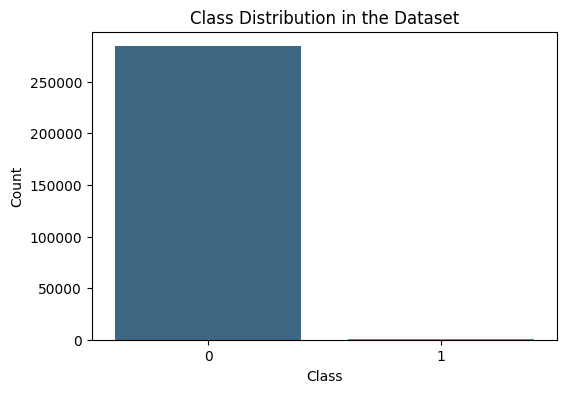

In [4]:
plt.figure(figsize=(6, 4))
sns.countplot(x='Class', data=df, palette='viridis')
plt.title('Class Distribution in the Dataset')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

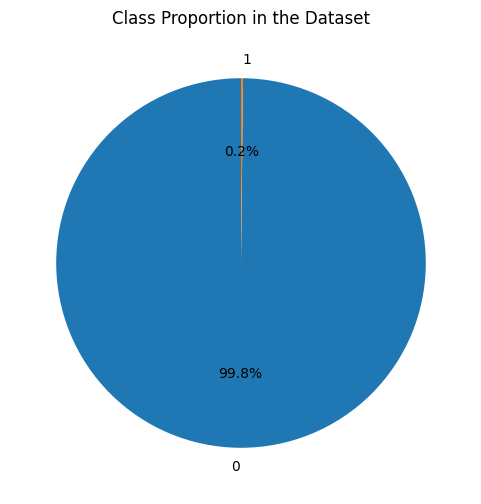

In [5]:
plt.figure(figsize=(6, 6))
class_counts = df['Class'].value_counts()
plt.pie(class_counts, labels=class_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Class Proportion in the Dataset')
plt.show()

In [6]:
X = df.drop('Class', axis=1)
y = df['Class']

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

In [8]:
def evaluate_model(X_train, y_train, X_test, y_test, classifier, description=""):
    
    classifier.fit(X_train, y_train)
    y_pred = classifier.predict(X_test)
    
    # Compute AUC if the classifier supports predict_proba
    if hasattr(classifier, "predict_proba"):
        y_prob = classifier.predict_proba(X_test)[:, 1]
        auc = roc_auc_score(y_test, y_prob)
    else:
        auc = None
    
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    return {
        'description': description,
        'accuracy': acc,
        'f1_score': f1,
        'auc': auc
    }


In [9]:
results = []

In [10]:
clf_original = DecisionTreeClassifier(random_state=42)
results.append(evaluate_model(X_train, y_train, X_test, y_test, 
                              classifier=clf_original,
                              description="Original Imbalanced Data"))

In [11]:
ros = RandomOverSampler(random_state=42)
X_train_ros, y_train_ros = ros.fit_resample(X_train, y_train)
clf_ros = DecisionTreeClassifier(random_state=42)
results.append(evaluate_model(X_train_ros, y_train_ros, X_test, y_test, 
                              classifier=clf_ros,
                              description="Random Oversampling"))

In [12]:
rus = RandomUnderSampler(random_state=42)
X_train_rus, y_train_rus = rus.fit_resample(X_train, y_train)
clf_rus = DecisionTreeClassifier(random_state=42)
results.append(evaluate_model(X_train_rus, y_train_rus, X_test, y_test, 
                              classifier=clf_rus,
                              description="Random Undersampling"))

In [13]:
tl = TomekLinks()
X_train_tl, y_train_tl = tl.fit_resample(X_train, y_train)
clf_tl = DecisionTreeClassifier(random_state=42)
results.append(evaluate_model(X_train_tl, y_train_tl, X_test, y_test, 
                              classifier=clf_tl,
                              description="Tomek Links"))

In [14]:
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
clf_smote = DecisionTreeClassifier(random_state=42)
results.append(evaluate_model(X_train_smote, y_train_smote, X_test, y_test, 
                              classifier=clf_smote,
                              description="SMOTE"))

In [15]:
clf_weighted = DecisionTreeClassifier(random_state=42, class_weight='balanced')
results.append(evaluate_model(X_train, y_train, X_test, y_test, 
                              classifier=clf_weighted,
                              description="Class Weighting"))

In [16]:
print("Model Performance Comparison:")
for res in results:
    print("\nTechnique:", res['description'])
    print(f"Accuracy: {res['accuracy']:.4f}")
    print(f"F1 Score: {res['f1_score']:.4f}")
    if res['auc'] is not None:
        print(f"AUC: {res['auc']:.4f}")

Model Performance Comparison:

Technique: Original Imbalanced Data
Accuracy: 0.9992
F1 Score: 0.7569
AUC: 0.8681

Technique: Random Oversampling
Accuracy: 0.9991
F1 Score: 0.7163
AUC: 0.8410

Technique: Random Undersampling
Accuracy: 0.8867
F1 Score: 0.0265
AUC: 0.8893

Technique: Tomek Links
Accuracy: 0.9992
F1 Score: 0.7543
AUC: 0.8681

Technique: SMOTE
Accuracy: 0.9978
F1 Score: 0.5317
AUC: 0.8673

Technique: Class Weighting
Accuracy: 0.9991
F1 Score: 0.7174
AUC: 0.8343


In [ ]:
results_df = pd.DataFrame(results)
results_df = results_df[['description', 'accuracy', 'f1_score', 'auc']]

results_df[['accuracy', 'f1_score', 'auc']] = results_df[['accuracy', 'f1_score', 'auc']].round(4)

print("Model Performance Comparison Table:")
display(results_df)


Model Performance Comparison Table:


,description,accuracy,f1_score,auc
0,Original Imbalanced Data,0.9992,0.7569,0.8681
1,Random Oversampling,0.9991,0.7163,0.8410
2,Random Undersampling,0.8867,0.0265,0.8893
3,Tomek Links,0.9992,0.7543,0.8681
4,SMOTE,0.9978,0.5317,0.8673
5,Class Weighting,0.9991,0.7174,0.8343


In [17]:
#finish